In [1]:
import os


os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


from functools import partial

import jax
import mediapy
from utils import expert_step, run_and_log_scenario
from waymax import dynamics

from vmax import PATH_TO_PROJECT
from vmax.simulator import datasets, make_data_generator, make_env, visualization

In [3]:
MAX_NUM_OBJECTS = 64
INCLUDE_SDC_PATHS = True
SEED = 0
path_dataset = "/media/rtgtx7/加速盘/data/validation.tfrecord"  # TO FILL


data_generator = make_data_generator(
    path=path_dataset,
    max_num_objects=MAX_NUM_OBJECTS,
    include_sdc_paths=INCLUDE_SDC_PATHS,
    seed=SEED,
)

env = make_env(
    max_num_objects=MAX_NUM_OBJECTS,
    dynamics_model=dynamics.InvertibleBicycleModel(normalize_actions=True),
    observation_type="vec",
    observation_config={
        "obs_past_num_steps": 5,
        "objects": {
            "features": ["waypoints", "velocity", "yaw", "size", "valid"],
            "num_closest_objects": 8,
        },
        "roadgraphs": {
            "features": ["waypoints", "types", "direction", "valid"],
            "meters_box": {"front": 50, "back": 5, "left": 20, "right": 20},
            "element_types": ["road_edge"],
            "max_meters": 50,
            "roadgraph_top_k": 256,
            "interval": 2,
        },
        "traffic_lights": {
            "features": ["waypoints", "state", "valid"],
            "num_closest_traffic_lights": 5,
        },
        "path_target": {
            "features": ["waypoints"],
            "num_points": 10,
            "points_gap": 5,
        },
    },
)

ValueError: Metric run_red_light has already been registered.

In [4]:
scenario = next(data_generator)
simulator_state = env.reset(scenario)

W0000 00:00:1765608300.553632  554070 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1765608300.559028  554070 gpu_device.cc:2431] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1765608300.651818  554070 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13132 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0


E1213 01:45:15.429913  554070 hlo_lexer.cc:443] Failed to parse int literal: 57906653232081209837


""

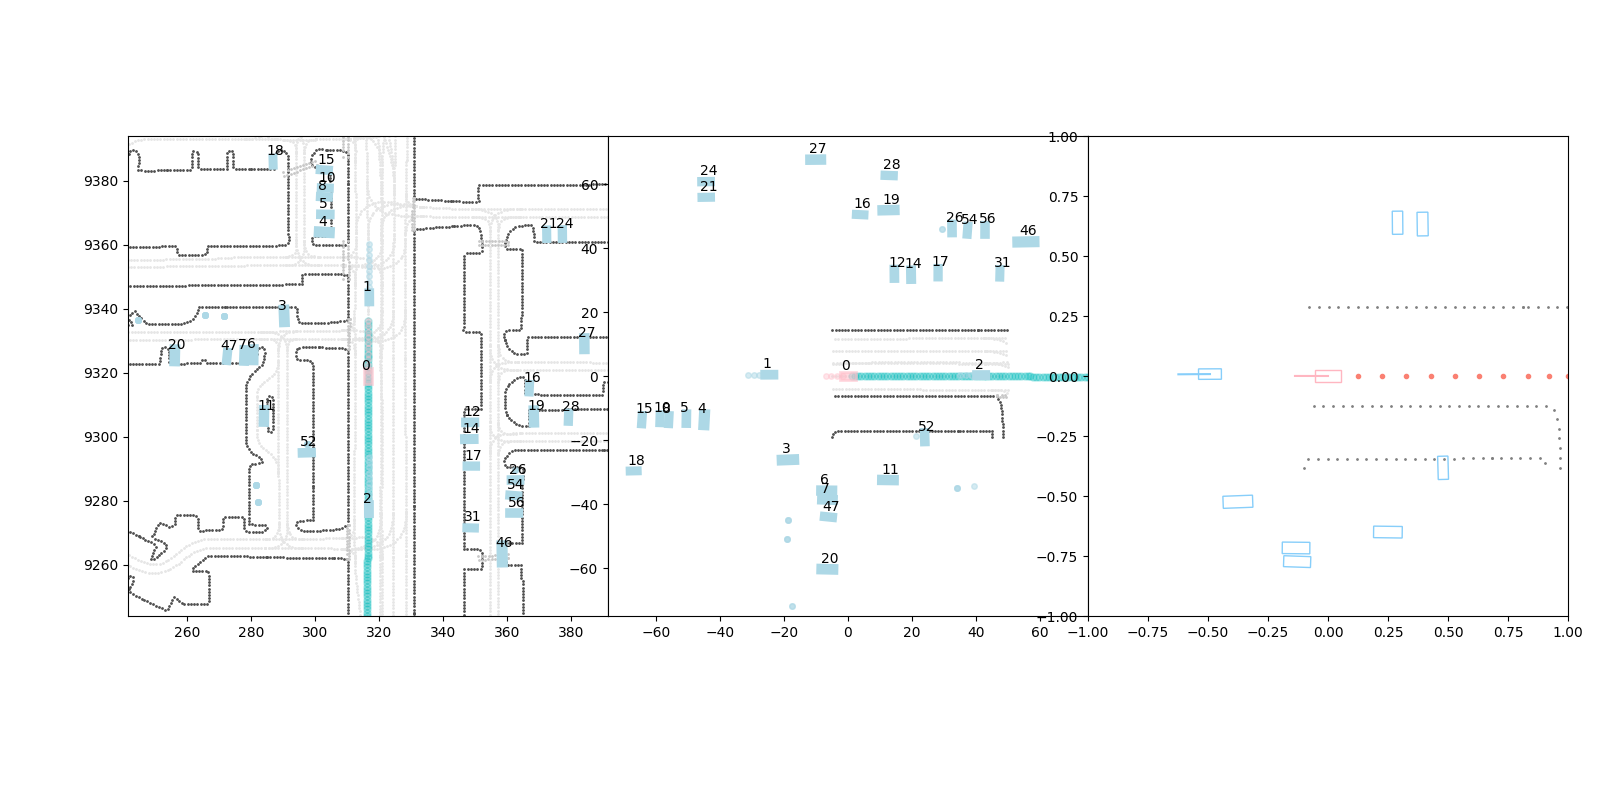

In [5]:
img = visualization.plot_input_agent(simulator_state, env)
mediapy.show_image(img)

In [9]:
_step = partial(expert_step, env)
_jitted_expert_step = jax.jit(_step)

In [11]:
for _i in range(0):
    scenario = next(data_generator)
    imgs = run_and_log_scenario(env, scenario, _jitted_expert_step)
    mediapy.show_video(imgs, fps=10)